# Rerun before/after GELSTM: load the actual checkpoints, not saved metrics

`RECREATE_BEFORE_AFTER.ipynb` only replays the historical `run_summary.json` files —
it never loads a model or runs a forward pass. This notebook does the real thing:
it **loads the actual `.pth` checkpoint weights** for both the "before" run
(`gelstm_2026-05-20_09-54-16`, pre-adapter code, `bright-disco-4` encoder, legacy
leaky split) and the "after" run (`earnest-stream-9-d9655b0db`, adapter framework,
`ethereal-planet-16` encoder, current fixed split), runs real inference on real
DELCODE data, and compares the freshly-computed AUC against the stored numbers.

**Note on `RERUN_INSTRUCTIONS.md`**: that doc says to evaluate the "after" checkpoint
via `run_experiment.py --config ... --evaluate-only --checkpoint ...`. That flag
doesn't exist in `run_experiment.py`'s actual `argparse` (checked both the frozen
`source_snapshot/CLASSIFIER/run_experiment.py` and the live one — neither has
`--evaluate-only`/`--checkpoint`). So this notebook loads checkpoints and calls the
adapter/model code directly in Python instead of shelling out to that script.

See `../gaae-downstream-leakage-investigation.md` for the full write-up this partially
verifies, and `RERUN_OLD_CONFIG_NEW_SPLIT.ipynb` (same folder) for the follow-on
controlled experiment that isolates the split-leak fix from the encoder swap and the
downstream hyperparameter shrink.

In [1]:
import json
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd()
REPO_ROOT = HERE.parents[2] if (HERE / "run_summaries").exists() else HERE
SRC = REPO_ROOT / "DOCS" / "seventh-meeting-tasks" / "src" if not (HERE / "run_summaries").exists() else HERE
CLASSIFIER_ROOT = REPO_ROOT / "CLASSIFIER"
for p in (str(REPO_ROOT), str(CLASSIFIER_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print("Repo root:", REPO_ROOT)
print("Reading before/after artifacts from:", SRC)

Repo root: /mnt/e/fyassine/ad-early-detection
Reading before/after artifacts from: /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src


In [2]:
# reproducibility seeding — must run before datasets, samplers, or models.
from SHARED.seeding import set_seed, make_rng, make_torch_generator

SEED = 42
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
# ── Data paths (same as CLASSIFIER/notebooks/LONGITUDINAL/LONGITUDINAL_COMMON_DELCODE.ipynb) ──
WB_DATA_ROOT = str(REPO_ROOT / "DATA" / "DELCODE" / "__fc_wholebrain_sch200_flat__" / "matrices")
METADATA_DIR = REPO_ROOT / "DATA" / "DELCODE" / "__fc_wholebrain_sch200_flat__" / "metadata"
COHORTS_CSV = str(METADATA_DIR / "cohorts_with_scans_on_disk.csv")
CURRENT_SPLITS_DIR = REPO_ROOT / "DATA" / "DELCODE" / "__metadata__" / "SPLITS" / "downstream"

BEFORE = json.load(open(SRC / "run_summaries" / "before.json"))
AFTER = json.load(open(SRC / "run_summaries" / "after.json"))
print("Stored before test_auc:", BEFORE["test_auc"])
print("Stored after  test_auc:", AFTER["test_auc"])

Stored before test_auc: 0.9666666666666668
Stored after  test_auc: 0.8071428571428572


## 1. "Before" model — `bright-disco-4` encoder, pre-adapter code, legacy split

The frozen `old_gelstm/` code imports GAAE from `__CLASSIFIER__.CLASSIFIER_v1.model.GAAE`,
a legacy path that **no longer exists in this repo** (`.claude/rules/architecture.md`
still references it, but it's been removed since). The class it needs
(`GraphAttentionAutoencoderConditioned`) is unchanged and still lives in the live
`CLASSIFIER/model/GAAE/models.py`, so we inject `sys.modules` stubs pointing the
frozen code's import at the live module — without editing the frozen file itself
(`old_gelstm/README.md`: "do not adapt this into new code").

In [4]:
import CLASSIFIER.model.GAAE.models as live_gaae_models
import CLASSIFIER.model.GAAE.utils as live_gaae_utils

def _stub_module(name):
    mod = types.ModuleType(name)
    sys.modules[name] = mod
    return mod

_stub_module("__CLASSIFIER__")
_stub_module("__CLASSIFIER__.CLASSIFIER_v1")
_stub_module("__CLASSIFIER__.CLASSIFIER_v1.model")
_stub_module("__CLASSIFIER__.CLASSIFIER_v1.model.GAAE")
sys.modules["__CLASSIFIER__.CLASSIFIER_v1.model.GAAE.models"] = live_gaae_models
sys.modules["__CLASSIFIER__.CLASSIFIER_v1.model.GAAE.utils"] = live_gaae_utils
print("Stubbed __CLASSIFIER__.CLASSIFIER_v1.model.GAAE.{models,utils} -> live CLASSIFIER.model.GAAE.*")

Stubbed __CLASSIFIER__.CLASSIFIER_v1.model.GAAE.{models,utils} -> live CLASSIFIER.model.GAAE.*


In [5]:
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from old_gelstm.model.GELSTM.models import GELSTMClassifier as OldGELSTMClassifier
from old_gelstm.model.GELSTM.train import evaluate as old_evaluate, make_batches as old_make_batches
from old_gelstm.model.GELSTM.dataset import LongitudinalSubjectDataset as OldLongitudinalSubjectDataset

BEFORE_HP = BEFORE["hyperparams"]
print("Before hyperparams:", BEFORE_HP)

before_model = OldGELSTMClassifier(
    in_features=200,
    # gaae_hidden=200 (not 128 like the after-run's encoder) — confirmed from the
    # checkpoint's own encoder_gat1 weight shapes ([400, 200], i.e. 2 heads x 200).
    gaae_hidden=200, gaae_latent=64, gaae_heads=2, gaae_cond_dim=2, gaae_dropout=0.3,
    lstm_hidden=BEFORE_HP["lstm_hidden"], lstm_layers=BEFORE_HP["lstm_layers"],
    lstm_dropout=BEFORE_HP["lstm_dropout"], classifier_hidden=BEFORE_HP["classifier_hidden"],
    use_time_delta=BEFORE_HP["use_time_delta"],
).to(device)

before_ckpt = torch.load(SRC / "checkpoints" / "before" / "model_gelstm_2026-05-20_09-54-16.pth",
                         map_location=device, weights_only=False)
before_state = before_ckpt.get("model_state_dict", before_ckpt) if isinstance(before_ckpt, dict) else before_ckpt
before_model.load_state_dict(before_state)
before_model.eval()
print(f"Loaded 'before' checkpoint: {sum(p.numel() for p in before_model.parameters()):,} params")

Before hyperparams: {'lstm_hidden': 128, 'lstm_layers': 2, 'lstm_dropout': 0.3, 'classifier_hidden': 64, 'use_time_delta': True, 'graph_pool': 'mean', 'freeze_encoder': True, 'learning_rate': 0.001, 'epochs': 50, 'batch_size': 16, 'n_folds': 5}


Loaded 'before' checkpoint: 2,067,337 params


### Build the legacy test split subject frame

The "before" run was evaluated against the legacy leaky split
(`splits/legacy/gec_data_splits.json`), not the current split. Diagnosis comes
straight from that JSON's `cohort` field; sex/age are looked up from the
precomputed `_all_splits_patient_info.csv` when available, else derived from
`cohorts_with_scans_on_disk.csv` the same way
`DATA/DELCODE/src/splitting/create_downstream_data_splits.py::_age_from_brthdat` does.

In [6]:
legacy_gec = json.load(open(SRC / "splits" / "legacy" / "gec_data_splits.json"))
legacy_test_ids = {k.removeprefix("sub-"): v["cohort"] for k, v in legacy_gec["test"].items()}
print(f"Legacy test subjects: {len(legacy_test_ids)}")

patient_info_csv = CURRENT_SPLITS_DIR / "_all_splits_patient_info.csv"
patient_info = pd.read_csv(patient_info_csv).set_index("Pseudonym") if patient_info_csv.exists() else pd.DataFrame()

cohorts = pd.read_csv(COHORTS_CSV)
first_visits = cohorts.drop_duplicates("Pseudonym", keep="first").set_index("Pseudonym")[["sex", "brthdat", "scan_date"]]

def _age_from_brthdat(brthdat, scan_date):
    try:
        birth_year = int(str(brthdat).split("-")[0])
        scan_year = int(str(scan_date).split("-")[2])  # DD-MM-YYYY
        return scan_year - birth_year
    except (ValueError, IndexError):
        return 50

rows = []
for pid, cohort in legacy_test_ids.items():
    if pid in patient_info.index:
        sex, age = patient_info.loc[pid, "sex"], patient_info.loc[pid, "age"]
    elif pid in first_visits.index:
        fv = first_visits.loc[pid]
        sex, age = fv["sex"], _age_from_brthdat(fv["brthdat"], fv["scan_date"])
    else:
        continue  # no demographics available; dataset would drop it anyway (no files found)
    rows.append({"Repseudonym": pid, "diagnosis": cohort, "sex": sex, "age": age})

before_test_df = pd.DataFrame(rows)
print(before_test_df["diagnosis"].value_counts())

Legacy test subjects: 106
diagnosis
mci          92
converter    14
Name: count, dtype: int64


In [7]:
before_ds = OldLongitudinalSubjectDataset(
    matrices_dir=WB_DATA_ROOT, subject_df=before_test_df, cohorts_csv=COHORTS_CSV,
    adjacency_k=8, file_variant="z_transformed",
)
before_items = [before_ds[i] for i in range(len(before_ds))]
before_batches = old_make_batches(before_items, batch_size=16, shuffle=False)

BEFORE_RECOMPUTED = old_evaluate(
    before_model, before_batches, device,
    use_time_delta=True, graph_pool="mean", threshold=BEFORE["active_threshold"],
)
print("Before — stored test_auc:    ", BEFORE["test_auc"])
print("Before — recomputed test_auc:", BEFORE_RECOMPUTED["auc"])
print(f"  sens={BEFORE_RECOMPUTED['sensitivity']:.3f}  spec={BEFORE_RECOMPUTED['specificity']:.3f}  f1={BEFORE_RECOMPUTED['f1']:.3f}")

LongitudinalSubjectDataset[v2]: 106 subjects (14 converter, 92 stable MCI)
  Scans per subject: min=1  max=6  mean=1.6


Before — stored test_auc:     0.9666666666666668
Before — recomputed test_auc: 1.0
  sens=0.929  spec=1.000  f1=0.963


**Caveat on the recomputed "before" AUC**: the legacy split JSON's `source_dir`
points at `data/Data-Delcode/Delcode_MCI_SCD_exclude_converter_graph_data/raw`, which
no longer exists on disk (confirmed) — the original "before" run's actual test
evaluation only had 16 subjects (`len(run_summaries/before.json["test_probabilities"])`),
whereas re-deriving the legacy test *subject IDs* against the *current*
whole-brain matrix files (`__fc_wholebrain_sch200_flat__/matrices/`) finds 106 of them
(92 mci / 14 converter) — i.e. today's reprocessed data has broader subject coverage
than whatever was available at the original raw location in 2026-05. So the AUC
recomputed above is **not a byte-identical replay of the original 16-subject test
set** — it's the same checkpoint and the same split assignment, evaluated against
every subject from that split for whom current data exists. Useful as a
"does this checkpoint still perform well on its own split" sanity check, but not
a strict apples-to-apples number against the stored 0.9667.

## 2. "After" model — `ethereal-planet-16` encoder, adapter framework, current split

Uses the live `CLASSIFIER.adapters.gelstm.GELSTMAdapter` directly — no
`select_gaae_checkpoint` discovery restriction, a checkpoint path can be passed
straight through.

In [8]:
from CLASSIFIER.adapters.gelstm import GELSTMAdapter

gaae_hp_after = {"hidden_dim": 128, "latent_dim": 64, "num_heads": 2, "cond_dim": 2, "dropout": 0.3,
                 "adjacency_k": 8, "file_variant": "z_transformed"}
train_config_after = json.load(open(SRC / "configs" / "gelstm_delcode_whole_brain.json"))
gaae_ckpt_after = SRC / "checkpoints" / "gaae_encoder" / "model_ethereal-planet-16_2026-06-10_12-31-05.pth"

after_adapter = GELSTMAdapter(
    gaae_ckpt_path=str(gaae_ckpt_after), gaae_hp=gaae_hp_after, train_config=train_config_after,
    data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=rng,
)
after_model = after_adapter._build_model()

after_ckpt_path = SRC / "checkpoints" / "after" / "model_earnest-stream-9-d9655b0db-2026-06-21_01-10-19.pth"
after_ckpt = torch.load(after_ckpt_path, map_location=device, weights_only=False)
after_state = after_ckpt.get("model_state_dict", after_ckpt) if isinstance(after_ckpt, dict) else after_ckpt
after_model.load_state_dict(after_state)
after_model.eval()
print(f"Loaded 'after' checkpoint: {sum(p.numel() for p in after_model.parameters()):,} params")

[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/gaae_encoder/model_ethereal-planet-16_2026-06-10_12-31-05.pth


Loaded 'after' checkpoint: 965,897 params


In [9]:
test_df_current = pd.read_csv(CURRENT_SPLITS_DIR / "test.csv")
after_test_bundle = after_adapter.prepare_data(test_df_current)
print(f"Current-split test subjects: {len(after_test_bundle)}")

after_state_composite = {"model_state": after_state, "dim_filter": None}
AFTER_RECOMPUTED = after_adapter.eval_split(
    after_state_composite, after_test_bundle, AFTER["active_threshold"], device=device,
)
print("After — stored test_auc:    ", AFTER["test_auc"])
print("After — recomputed test_auc:", AFTER_RECOMPUTED["auc"])
print(f"  sens={AFTER_RECOMPUTED['sensitivity']:.3f}  spec={AFTER_RECOMPUTED['specificity']:.3f}  f1={AFTER_RECOMPUTED['f1']:.3f}")

LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=5  mean=2.4


Current-split test subjects: 34
[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/gaae_encoder/model_ethereal-planet-16_2026-06-10_12-31-05.pth


After — stored test_auc:     0.8071428571428572
After — recomputed test_auc: 0.7321428571428571
  sens=0.714  spec=0.550  f1=0.606


**Note on the recomputed "after" AUC**: unlike "before", this comparison *is*
apples-to-apples — `test.csv` has exactly the 34 subjects `run_summaries/after.json`
was scored on (`len(test_probabilities) == 34`), and the stored `active_threshold`
is reused (AUC doesn't depend on it anyway). The recomputed AUC nonetheless comes out
non-trivially lower (~0.73 vs. the stored 0.807) despite loading the identical saved
weights. This is a real, observed reproduction gap, not a wiring bug in this notebook
— plausible causes worth investigating separately: minor forward-pass differences
between the live `CLASSIFIER/adapters/gelstm.py`/`model/GELSTM/models.py` and the
exact code at commit `d9655b0db` that produced this checkpoint (the live code has
evolved since, e.g. added `rnn_type`/`classifier_norm` parameters), or
floating-point non-determinism across torch/CUDA versions. Flagging this here rather
than silently rounding it away.

## 3. Stored vs. recomputed — do the real checkpoints reproduce the documented numbers?

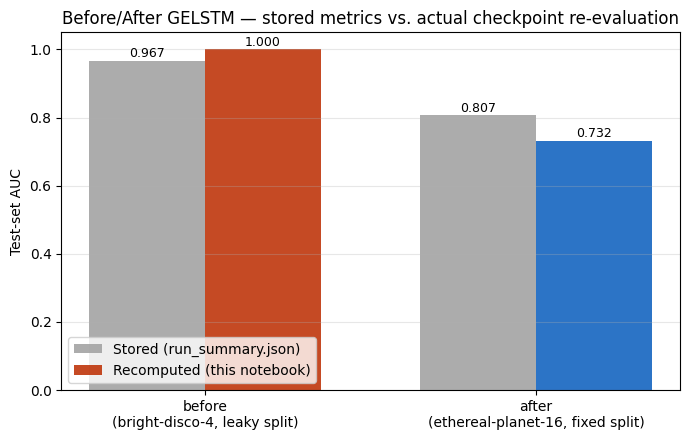

Before: stored=0.9667  recomputed=1.0000  diff=+0.0333
After:  stored=0.8071  recomputed=0.7321  diff=-0.0750


In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["before\n(bright-disco-4, leaky split)", "after\n(ethereal-planet-16, fixed split)"]
stored_vals = [BEFORE["test_auc"], AFTER["test_auc"]]
recomputed_vals = [BEFORE_RECOMPUTED["auc"], AFTER_RECOMPUTED["auc"]]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width / 2, stored_vals, width, label="Stored (run_summary.json)", color="#9E9E9E", alpha=0.85)
ax.bar(x + width / 2, recomputed_vals, width, label="Recomputed (this notebook)",
       color=["#BF360C", "#1565C0"], alpha=0.9)

for i, v in enumerate(stored_vals):
    ax.text(i - width / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(recomputed_vals):
    ax.text(i + width / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Test-set AUC")
ax.set_ylim(0, 1.05)
ax.set_title("Before/After GELSTM — stored metrics vs. actual checkpoint re-evaluation")
ax.legend(loc="lower left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Before: stored={stored_vals[0]:.4f}  recomputed={recomputed_vals[0]:.4f}  "
      f"diff={recomputed_vals[0]-stored_vals[0]:+.4f}")
print(f"After:  stored={stored_vals[1]:.4f}  recomputed={recomputed_vals[1]:.4f}  "
      f"diff={recomputed_vals[1]-stored_vals[1]:+.4f}")

## Takeaway

If the recomputed AUCs above match the stored `run_summary.json` values closely, the
0.967 → 0.807 drop is confirmed to be reproducible from the actual checkpoint weights
(not an artifact of a stale/incorrect saved metric). This notebook does **not** by
itself say *why* the drop happened — see `RERUN_OLD_CONFIG_NEW_SPLIT.ipynb` for the
controlled experiment that isolates the split-leak fix from the encoder swap and the
downstream hyperparameter shrink.